In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
data=pd.read_csv(r"C:\Users\DELL\Documents\Development\Python\Project 1\TSLA.csv",index_col=0)

In [84]:
#1
l=data.shape
print("rows = ",l[0])
print("cols = ", l[1])


rows =  2579
cols =  6


In [85]:
#2
data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500
2010-07-07,3.280,3.326,2.996,3.160,3.160,34608500


In [86]:
#2 last 10
data.tail(10)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-09-14,380.950012,420.000000,373.299988,419.619995,419.619995,83020600
2020-09-15,436.559998,461.940002,430.700012,449.760010,449.760010,97298200
2020-09-16,439.869995,457.790009,435.309998,441.760010,441.760010,72279300
2020-09-17,415.600006,437.790009,408.000000,423.429993,423.429993,76779200
2020-09-18,447.940002,451.000000,428.799988,442.149994,442.149994,86406800
2020-09-21,453.130005,455.679993,407.070007,449.390015,449.390015,109476800
2020-09-22,429.600006,437.760010,417.600006,424.230011,424.230011,79580800
2020-09-23,405.160004,412.149994,375.880005,380.359985,380.359985,95074200
2020-09-24,363.799988,399.500000,351.299988,387.790009,387.790009,96561100


In [87]:
#3
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2579 entries, 2010-06-30 to 2020-09-25
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2579 non-null   float64
 1   High       2579 non-null   float64
 2   Low        2579 non-null   float64
 3   Close      2579 non-null   float64
 4   Adj Close  2579 non-null   float64
 5   Volume     2579 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 141.0+ KB


In [88]:
#4
numerical_cols = data.select_dtypes(include='number').columns

result = pd.DataFrame({
    "Attribute": numerical_cols,
    "Min": data[numerical_cols].min().values,
    "Max": data[numerical_cols].max().values
})


result

,Attribute,Min,Max
0,Open,3.228,5.021400e+02
1,High,3.326,5.024900e+02
2,Low,2.996,4.705100e+02
3,Close,3.160,4.983200e+02
4,Adj Close,3.160,4.983200e+02
5,Volume,592500.000,3.046940e+08


In [89]:
#5
data.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [90]:
#7
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2579.000000,2579.000000,2579.000000,2579.000000,2579.000000,2.579000e+03
mean,49.206686,50.301806,48.073117,49.253279,49.253279,3.078217e+07
std,57.934102,59.888383,55.852349,58.119783,58.119783,2.855717e+07
min,3.228000,3.326000,2.996000,3.160000,3.160000,5.925000e+05
25%,7.159000,7.268000,6.989000,7.153000,7.153000,1.047400e+07
50%,44.001999,44.660000,43.301998,43.924000,43.924000,2.413100e+07
75%,59.339000,60.171000,57.841000,59.020000,59.020000,3.979150e+07
max,502.140015,502.489990,470.510010,498.320007,498.320007,3.046940e+08


<Axes: >

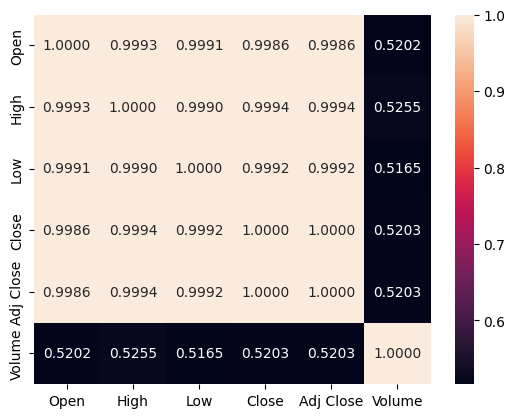

In [91]:
#8
sns.heatmap(data.corr(), annot=True,fmt=".4f")

In [92]:
#9
data.index = pd.to_datetime(data.index)

print(data.index.dtype)

datetime64[ns]


In [94]:
#10
new=data.loc[data.High>450]
new[['Open']]

,Open
Date,
2020-08-27,436.092010
2020-08-28,459.023987
2020-08-31,444.609985
2020-09-01,502.140015
2020-09-02,478.989990
2020-09-15,436.559998
2020-09-16,439.869995
2020-09-18,447.940002
2020-09-21,453.130005


In [95]:
#11
top10 = data.sort_values(by="Close", ascending=False).head(10).reset_index()[["Date", "High"]]
top10

,Date,High
0,2020-08-31,500.140015
1,2020-09-01,502.489990
2,2020-09-15,461.940002
3,2020-09-21,455.679993
4,2020-08-27,459.119995
5,2020-09-02,479.040009
6,2020-08-28,463.697998
7,2020-09-18,451.000000
8,2020-09-16,457.790009
9,2020-08-26,433.200012


In [96]:
#12
bot10 = data.sort_values(by="Open", ascending=True).head(10).reset_index()[["Date", "Low"]]
bot10

,Date,Low
0,2010-07-08,3.114
1,2010-07-07,2.996
2,2010-07-13,3.380
3,2010-07-09,3.310
4,2010-08-12,3.478
5,2010-07-14,3.552
6,2010-07-12,3.400
7,2010-08-13,3.532
8,2010-08-16,3.652
9,2010-08-19,3.666


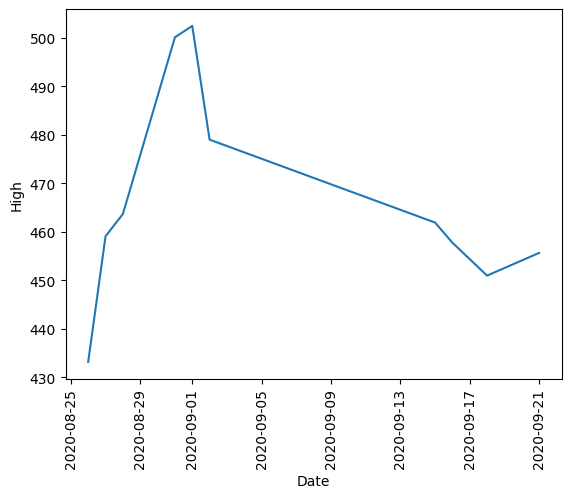

In [ ]:
#13
sns.lineplot(data=top10, x="Date", y="High")
plt.xlabel("Date")
plt.ylabel("High")
plt.xticks(rotation=90)

plt.show()

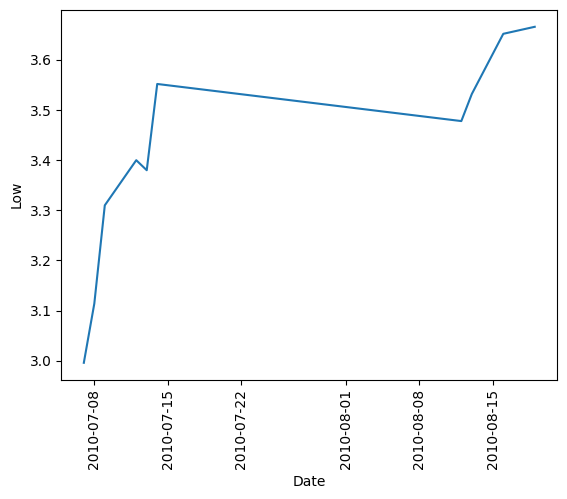

In [102]:
#14
sns.lineplot(data=bot10, x="Date", y="Low")
plt.xlabel("Date")
plt.ylabel("Low")
plt.xticks(rotation=90)

plt.show()

In [104]:
#15
new_df = data.loc[(data["Volume"] >= 1000000) & (data["Volume"] <= 1500000),["Volume"]]
new_df

,Volume
Date,
2010-08-20,1480000
2010-08-31,1005500
2010-09-07,1217000
2010-09-08,1442000
2010-10-08,1339000
2010-10-12,1220000
2010-10-14,1474000
2010-10-15,1423500
2010-10-19,1226000


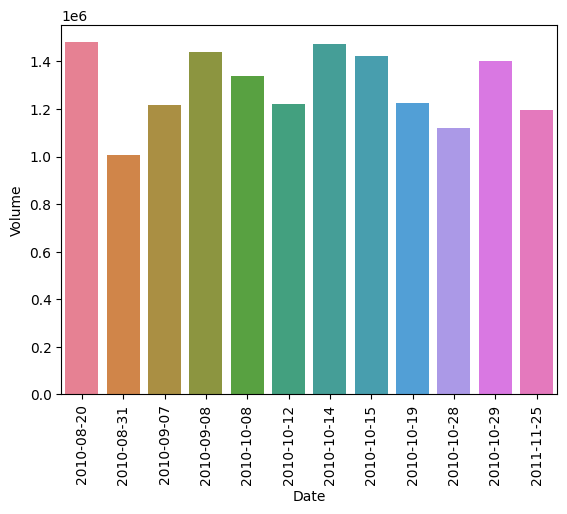

In [ ]:
#16
sns.barplot(x=new_df.index,y=new_df.Volume,hue=new_df.index)
plt.xticks(rotation=90)
plt.show()

In [109]:
#17
eq=data[data.Open==data.Close][["High","Low"]]
eq

,High,Low
Date,,
2010-10-08,4.158000,4.078
2011-02-11,4.750000,4.588
2012-03-07,6.662000,6.582
2012-04-24,6.440000,6.200
2012-07-06,6.346000,6.160
2019-12-17,77.099998,75.180


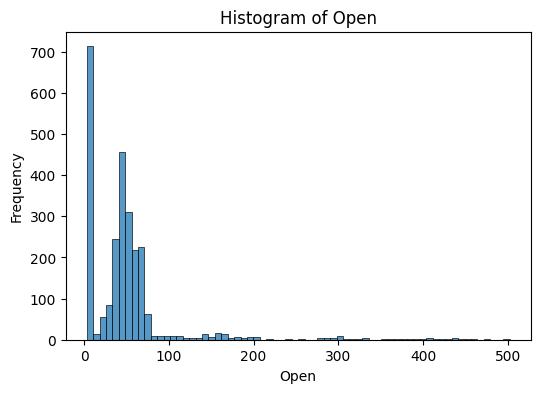

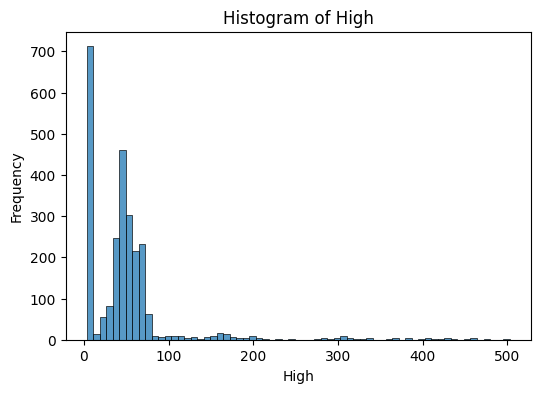

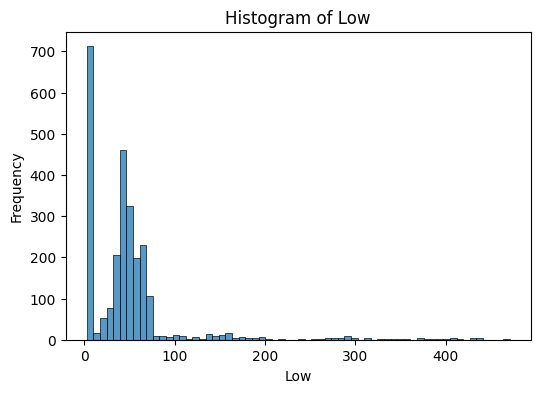

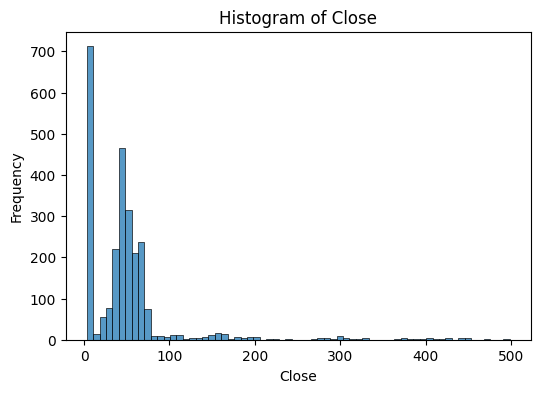

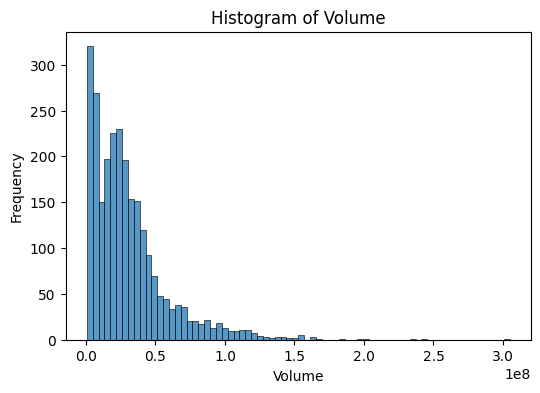

In [111]:
#18
attributes = ["Open","High","Low","Close","Volume"]

for col in attributes:
    plt.figure(figsize=(6,4))
    sns.histplot(data=data,x=col)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

<Axes: xlabel='Open', ylabel='Close'>

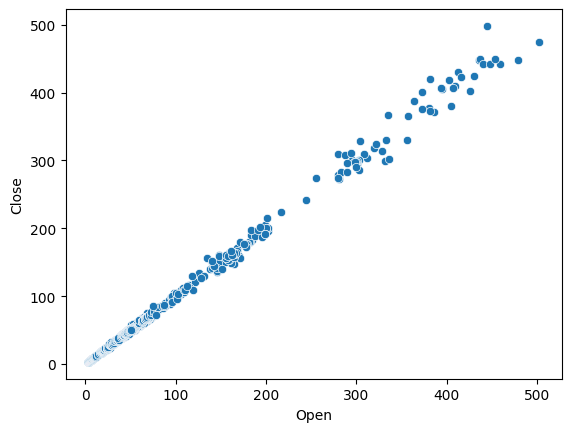

In [112]:
#19
sns.scatterplot(x=data.Open,y=data.Close)

<Axes: xlabel='High', ylabel='Low'>

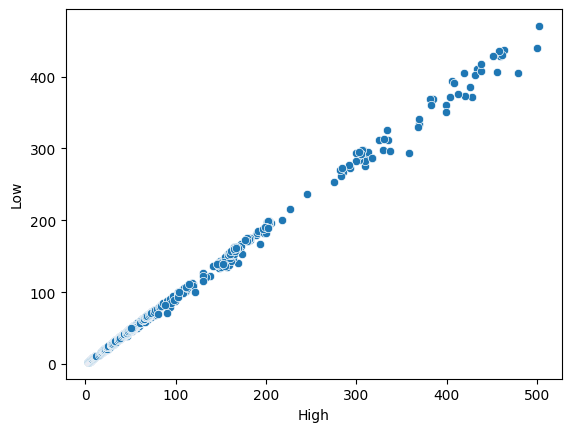

In [113]:
sns.scatterplot(x=data.High,y=data.Low)

<Axes: xlabel='Volume', ylabel='Adj Close'>

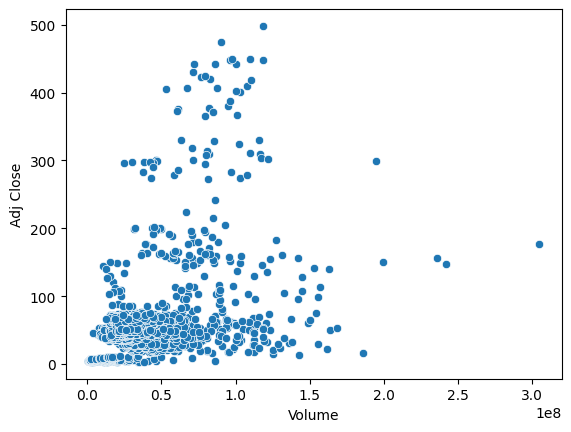

In [115]:
sns.scatterplot(x=data.Volume,y=data["Adj Close"])